In [1]:
import pandas as pd

df = pd.read_csv("amz_uk_price_prediction_dataset.csv")
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


In [3]:
df.isna().sum()

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.describe()

,uid,stars,reviews,price,boughtInLastMonth
count,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06
mean,1.370545e+06,2.152836e+00,4.806278e+02,8.924381e+01,2.589699e+01
std,8.160562e+05,2.194865e+00,5.944124e+03,3.456089e+02,2.404837e+02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.589215e+05,0.000000e+00,0.000000e+00,9.990000e+00,0.000000e+00
50%,1.349029e+06,0.000000e+00,0.000000e+00,1.909000e+01,0.000000e+00
75%,2.060686e+06,4.400000e+00,5.900000e+01,4.599000e+01,0.000000e+00
max,2.828593e+06,5.000000e+00,1.356658e+06,1.000000e+05,5.000000e+04


In [7]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

The lab refers to the product rating column as `rating`, but in this dataset it is named `stars`, so I used `stars` for the rating analysis.

The dataset does not contain missing values or duplicate rows. The `price` and `stars` columns are already numeric, and no invalid values were found. Product prices are all non-negative, and product ratings are within the expected 0 to 5 range. Therefore, no major data cleaning was required before analysis.

In [21]:
# Frequency table for product categories
category_frequency = df["category"].value_counts()

category_frequency

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [22]:
# Top 5 most listed product categories
top_5_categories = category_frequency.head(5)

top_5_categories

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

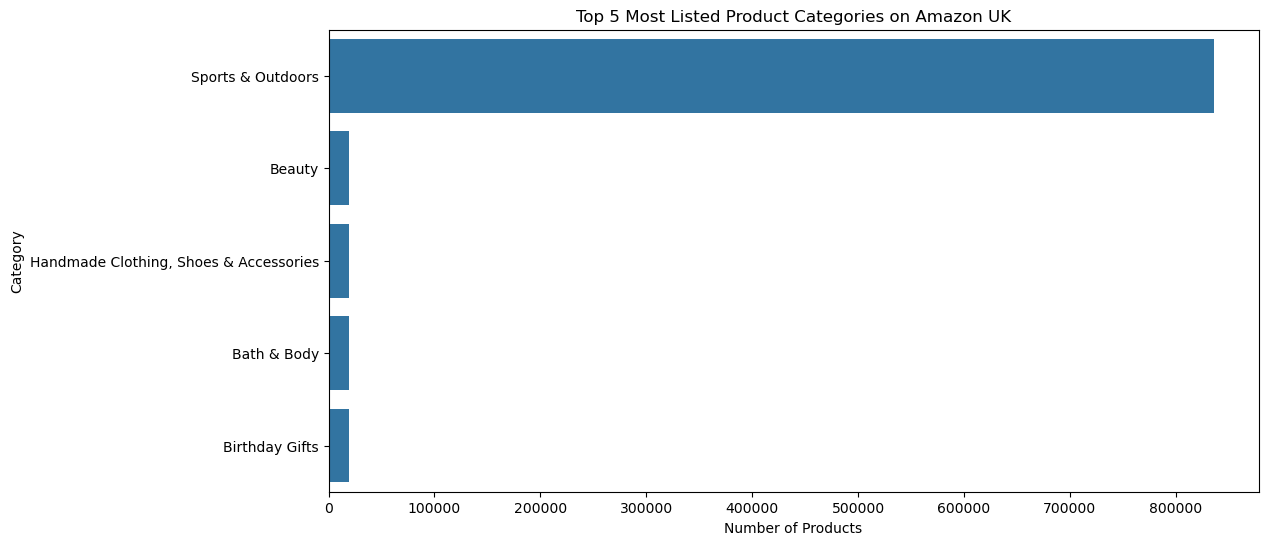

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_5_categories.values,
    y=top_5_categories.index
)

plt.title("Top 5 Most Listed Product Categories on Amazon UK")
plt.xlabel("Number of Products")
plt.ylabel("Category")
plt.show()

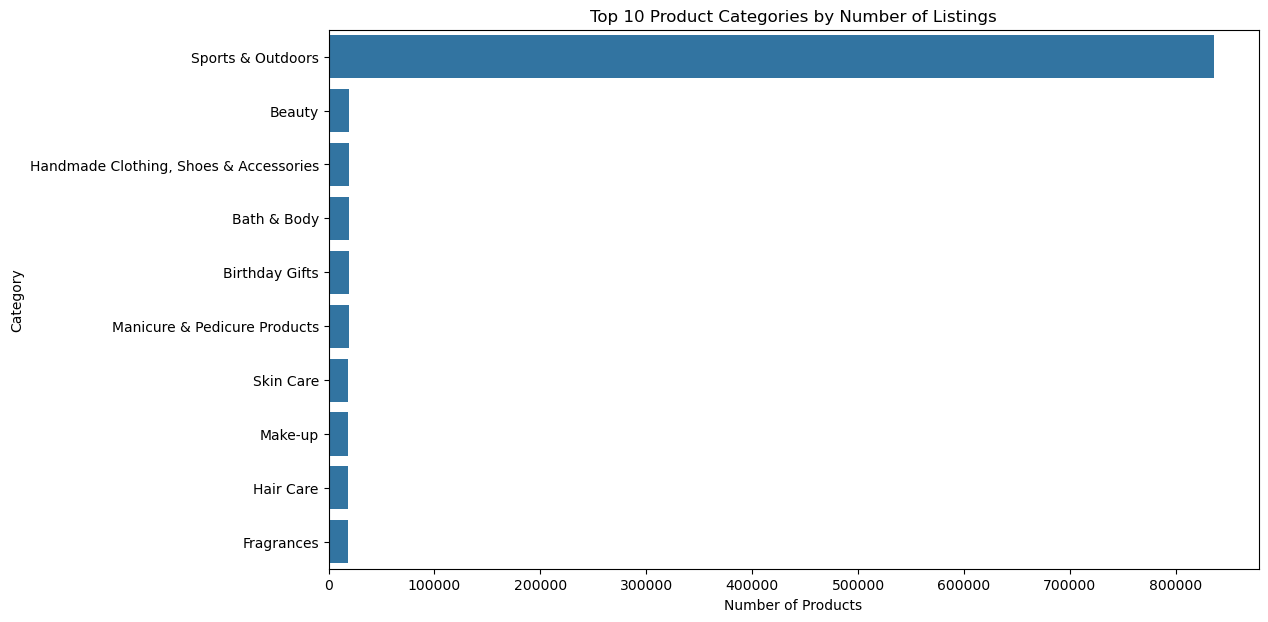

In [25]:
# Top 10 categories
top_10_categories = df["category"].value_counts().head(10)

plt.figure(figsize=(12, 7))
sns.barplot(
    x=top_10_categories.values,
    y=top_10_categories.index
)

plt.title("Top 10 Product Categories by Number of Listings")
plt.xlabel("Number of Products")
plt.ylabel("Category")
plt.show()

The leading category dominates the listings compared to the other top categories, suggesting that this product type has a much stronger presence on Amazon UK.

In [27]:
price_centrality = pd.DataFrame({
    "Measure": ["Mean", "Median", "Mode"],
    "Value": [price_mean, price_median, price_mode]
})

price_centrality

,Measure,Value
0,Mean,89.243809
1,Median,19.090000
2,Mode,9.990000


In [29]:
# Measures of dispersion for product prices
price_variance = df["price"].var()
price_std = df["price"].std()
price_range = df["price"].max() - df["price"].min()
price_iqr = df["price"].quantile(0.75) - df["price"].quantile(0.25)

price_dispersion = pd.DataFrame({
    "Measure": ["Variance", "Standard Deviation", "Range", "IQR"],
    "Value": [price_variance, price_std, price_range, price_iqr]
})

price_dispersion

,Measure,Value
0,Variance,119445.485323
1,Standard Deviation,345.608862
2,Range,100000.000000
3,IQR,36.000000


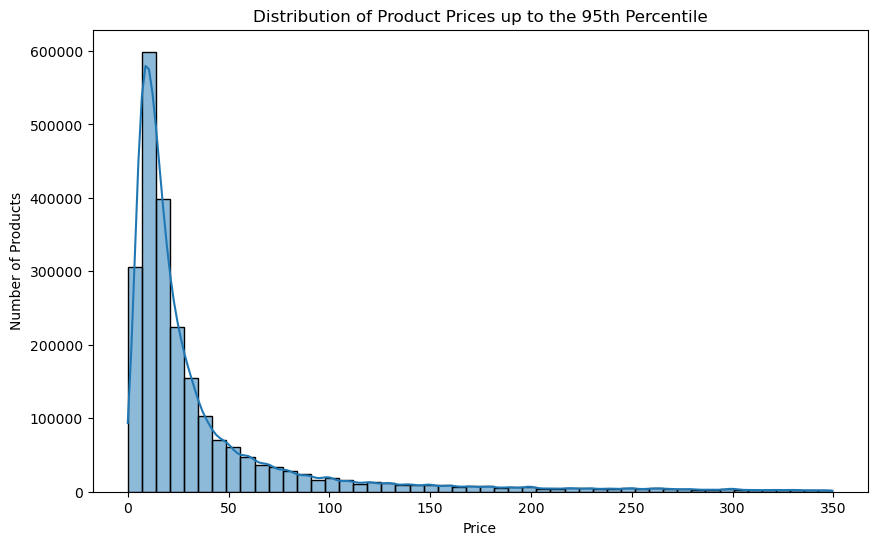

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(df[df["price"] <= df["price"].quantile(0.95)]["price"], bins=50, kde=True)

plt.title("Distribution of Product Prices up to the 95th Percentile")
plt.xlabel("Price")
plt.ylabel("Number of Products")
plt.show()

In [34]:
price_95 = df["price"].quantile(0.95)

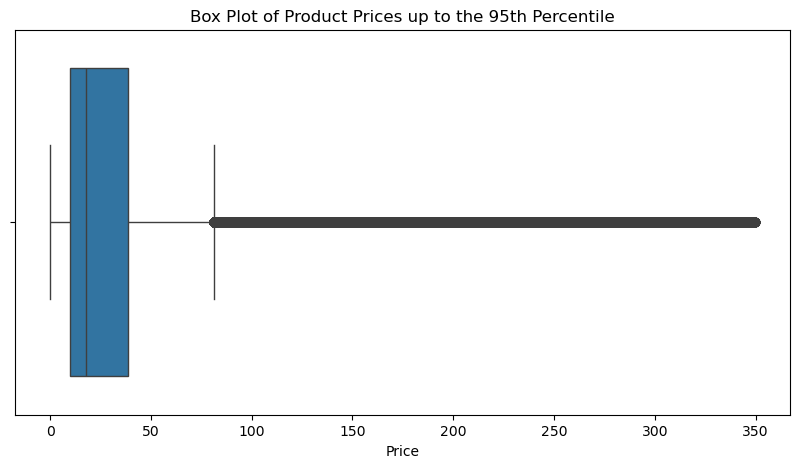

In [35]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df[df["price"] <= price_95]["price"])

plt.title("Box Plot of Product Prices up to the 95th Percentile")
plt.xlabel("Price")
plt.show()

The product price distribution is right-skewed, meaning most products are priced at the lower end while a smaller number of products are much more expensive. The full histogram and box plot show the presence of high-priced outliers, which makes the distribution harder to read. To better understand where most products fall, prices up to the 95th percentile were also visualized. This makes the common price range clearer while still recognizing that extreme prices exist.

In [37]:
# Measures of centrality for product ratings
stars_mean = df["stars"].mean()
stars_median = df["stars"].median()
stars_mode = df["stars"].mode()[0]

stars_centrality = pd.DataFrame({
    "Measure": ["Mean", "Median", "Mode"],
    "Value": [stars_mean, stars_median, stars_mode]
})

stars_centrality

,Measure,Value
0,Mean,2.152836
1,Median,0.000000
2,Mode,0.000000


In [38]:
# Measures of centrality for product ratings
stars_mean = df["stars"].mean()
stars_median = df["stars"].median()
stars_mode = df["stars"].mode()[0]

stars_centrality = pd.DataFrame({
    "Measure": ["Mean", "Median", "Mode"],
    "Value": [stars_mean, stars_median, stars_mode]
})

stars_centrality

,Measure,Value
0,Mean,2.152836
1,Median,0.000000
2,Mode,0.000000


In [39]:
# Measures of dispersion for product ratings
stars_variance = df["stars"].var()
stars_std = df["stars"].std()
stars_iqr = df["stars"].quantile(0.75) - df["stars"].quantile(0.25)

stars_dispersion = pd.DataFrame({
    "Measure": ["Variance", "Standard Deviation", "IQR"],
    "Value": [stars_variance, stars_std, stars_iqr]
})

stars_dispersion

,Measure,Value
0,Variance,4.817434
1,Standard Deviation,2.194865
2,IQR,4.400000


In [40]:
# Skewness and kurtosis for product ratings
stars_skewness = df["stars"].skew()
stars_kurtosis = df["stars"].kurt()

stars_shape = pd.DataFrame({
    "Measure": ["Skewness", "Kurtosis"],
    "Value": [stars_skewness, stars_kurtosis]
})

stars_shape

,Measure,Value
0,Skewness,0.081207
1,Kurtosis,-1.926006


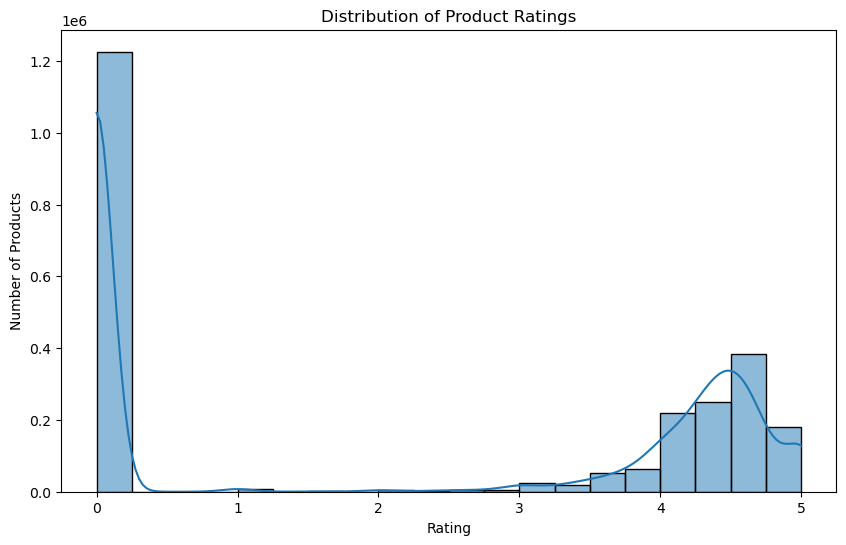

In [41]:
plt.figure(figsize=(10, 6))
sns.histplot(df["stars"], bins=20, kde=True)

plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.show()

The skewness value is very close to zero. This suggests that the distribution of product ratings is almost symmetrical, with only a very slight right skew. The kurtosis value indicates a flatter distribution than a normal distribution. Therefore, the ratings are not strongly normally distributed and are spread more evenly rather than being concentrated around one central rating.

## Findings

This analysis explored Amazon UK product listings using category, price, and rating information. The dataset contains 2,443,651 products and did not require major cleaning because there were no missing values, duplicate rows, or invalid values in the key columns.

For product categories, `Sports & Outdoors` is the most listed category by a very large margin, with 836,265 products. This represents about 34.2% of all listings. The next categories, such as `Beauty`, `Handmade Clothing, Shoes & Accessories`, `Bath & Body`, and `Birthday Gifts`, each have around 19,000 listings. This shows that `Sports & Outdoors` strongly dominates the dataset compared with other categories.

For product prices, the mean price is 89.24, while the median price is 19.09 and the mode is 9.99. Since the mean is much higher than the median, the price distribution is right-skewed. Most products are priced at the lower end, but some very expensive products increase the average. The standard deviation is 345.61, the range is 100,000, and the IQR is 36.00, showing that prices vary widely and include strong outliers. The 95th percentile visualization helps show the common price range more clearly.

For product ratings, the `stars` column was used because the dataset does not have a column named `rating`. The mean rating is 2.15, while both the median and mode are 0. This suggests that many products may have no rating recorded or are unrated. The standard deviation is 2.19 and the IQR is 4.40, showing a wide spread in ratings. The skewness value is 0.081, which is close to zero, so the rating distribution is almost symmetrical. The kurtosis value is -1.926, meaning the distribution is flatter than a normal distribution and not strongly concentrated around one central rating.

Overall, Amazon UK listings in this dataset are heavily concentrated in `Sports & Outdoors`, product prices are highly right-skewed with many low-priced products and some extreme high-priced outliers, and ratings show a large number of zero values, which may represent unrated products.